# Installation <a name="installation"></a>

First, we need to install the necessary libraries. This includes TabPFN and TabICLv2, as well as other libraries for data manipulation and baseline model comparisons.

Restart the runtime after installation.


In [ ]:
## Base library Installation
!uv venv

# Install uv into notebook environment
!pip install uv

# Install Baselines for model comparison
!uv pip install catboost xgboost

# Install the datasets library for loading example data
!uv pip install datasets

# Install rich for better and more readable printing
!uv pip install rich

## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!uv pip install tabpfn-client

# Install TabPFN extensions for additional functionalities
!uv pip install 'tabpfn-extensions[all]'

# Install tabpfn
!uv pip install tabpfn

# Install tabicl
!uv pip install tabicl

Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Activate with: source .venv/bin/activate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.8/24.8 MB 55.0 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 21 packages in 251ms
Prepared 1 package in 1.18s
Installed 1 package in 3ms
 + catboost==1.2.10
Using Python 3.12.13 environment at: /usr
Checked 1 package in 109ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 101ms
Using Python 3.12.13 environment at: /usr
Resolved 33 packages in 157ms
Prepared 5 packages in 40ms
Uninstalled 1 package in 3ms
Installed 5 packages in 8ms
 + backoff==2.2.1
 + password-strength==0.0.3.post2
 + sseclient-py==1.8.0
 + tabpfn-client==0.2.8
 - tqdm==4.67.3
 + tqdm==4.67.1
Using Python 3.12.13 environment at: /usr
Resolved 106 packages in 1.31s
Prepared 18 packages in 522ms
Uninstalled 1 package in 1ms
Installed 18 packages in 90ms
 + autogluon-common==1.4.0
 + autogluon-core==1.4.0

***Note: remember to restart the runtime after the installation.***

# Necessary Imports for the Notebook [Running this cell required!]

Now that the libraries are installed, let's import all the necessary modules for this notebook.




In [5]:
# Standard Library Imports

# TabPFN
from tabpfn import TabPFNRegressor

# TabICL

from tabicl import TabICLRegressor

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Other ML Models
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.rule import Rule
from sklearn.compose import make_column_selector, make_column_transformer

# Scikit-Learn: Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder


# This transformer will be used to handle categorical features
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)

# Backend Selection to run TabPFN


TabPFN can be run in two ways: locally on your machine (if you have a GPU) or by using the TabPFN client, which sends the data to a server for computation.
In your project you would either use the **local** version (which requires a GPU) with:
```python
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

or the **client** API (which uses a remote server):

```python
# Simple import for TabPFN
from tabpfn_client import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

If you select **local** and it's your first time using the model, you'll need to accept the license agreement and log into Hugging Face.
You'll be prompted with instructions on how to do this the first time you fit the model.

For demonstration purposes, the cell below provides an interactive way to switch between local mode and the client:


In [6]:
# Authentication code - No need to read it!

console = Console()

console.print(Panel.fit("[bold magenta]TabPFN Demo: Backend Selection[/bold magenta]"))
console.print("\nThis script can run TabPFN using one of two backends:")
console.print("  [bold]local:[/bold] Uses a local GPU (NVIDIA). Requires CUDA.")
console.print(
    "  [bold]client:[/bold] Uses the TabPFN API. Requires an internet connection and a free account."
)

backend = None
while backend is None:
  console.print(
      "\n[bold]Choose your backend[/bold]: - If no text box is shown, restart the cell.",
  )
  user_input = input("Enter 'local' or 'client' and press return:")
  if user_input not in ["local", "client"]:
    continue
  backend = user_input

console.print(
    f"\n✅ You have selected the '[bold green]{backend}[/bold green]' backend."
)

console.print(Rule(f"[bold]Setting up [cyan]{backend}[/cyan] backend[/bold]"))

if backend == "local":
    console.print("Attempting local backend setup...")
    import torch

    if not torch.cuda.is_available():
        console.print(
            "[bold red]Error:[/bold red] GPU device not found. For fast training, please enable GPU.",
            style="red",
        )
        console.print(
            "In Colab: Go to [bold]Runtime -> Change runtime type -> Hardware accelerator -> GPU.[/bold]",
            style="yellow",
        )
        raise SystemError("GPU device not found.")
    console.print("[bold green]✅ GPU is available.[/bold green]")

    # --- Prior Labs Authentication ---
    console.print(Rule("[bold]Prior Labs Authentication[/bold]"))
    console.print(
        "\nTabPFN model weights require a free [bold]Prior Labs account[/bold] and "
        "acceptance of the non-commercial license.\n"
    )

    import os
    import getpass

    tabpfn_token = None

    # 1. Try Colab secret TABPFN_TOKEN
    try:
        from google.colab import userdata
        tabpfn_token = userdata.get("TABPFN_TOKEN")
        if tabpfn_token:
            os.environ["TABPFN_TOKEN"] = tabpfn_token
            console.print("[bold green]✅ Found TABPFN_TOKEN in Colab secrets.[/bold green]")
    except Exception:
        pass

    # 2. If no token found, prompt the user
    if not tabpfn_token:
        console.print(
            Panel(
                "To get your access token:\n\n"
                "  1. Go to [link=https://ux.priorlabs.ai]ux.priorlabs.ai[/link] and sign up / log in\n"
                "  2. Accept the license at [link=https://ux.priorlabs.ai/account/licenses]ux.priorlabs.ai/account/licenses[/link]\n"
                "  3. Copy your Access Token from [link=https://ux.priorlabs.ai/account]ux.priorlabs.ai/account[/link]\n\n"
                "[bold yellow]Tip:[/bold yellow] Save the token as a Colab secret named "
                "[bold cyan]TABPFN_TOKEN[/bold cyan] to skip this step next time.",
                title="[bold]🔑 Prior Labs Access Token required",
                border_style="blue",
            )
        )
        while not tabpfn_token:
            token_input = getpass.getpass("Paste your TABPFN_TOKEN and press Enter: ")
            if token_input.strip():
                tabpfn_token = token_input.strip()
                os.environ["TABPFN_TOKEN"] = tabpfn_token
            else:
                console.print("[red]Token cannot be empty. Please try again.[/red]")

    console.print("")
    console.print("Importing local TabPFN library...")

    from tabpfn import TabPFNRegressor

    console.print("[bold green]✅ TabPFN (local) imported successfully.[/bold green]")
elif backend == "client":
    console.print("Attempting client backend setup...")
    console.print("Importing TabPFN client library...")
    from tabpfn_client import TabPFNRegressor, init

    init()
    console.print("[bold green]✅ TabPFN (client) initialized.[/bold green]")


╭────────────────────────────────╮
│ TabPFN Demo: Backend Selection │
╰────────────────────────────────╯

This script can run TabPFN using one of two backends:

local: Uses a local GPU (NVIDIA). Requires CUDA.

client: Uses the TabPFN API. Requires an internet connection and a free account.

Choose your backend: - If no text box is shown, restart the cell.

...

✅ You have selected the 'client' backend.

──────────────────────────────────────────── Setting up client backend ────────────────────────────────────────────

Attempting client backend setup...

Importing TabPFN client library...

✅ TabPFN (client) initialized.

# Loading methanol dehydrogenation and formic acid decomposition datasets from CPEC Chemical Catalysis Database


We will use the CPEC Chemical Catalysis Database CatTestHub dataset, where the goal is to predict the reaction rate from experimental parameters for methanol dehydrogenation and formic acid decomposition.

In [26]:
# Load both datasets
methanol_data = pd.read_csv('methanol_dehydrogenation_CatTestHub.csv', sep=';', encoding='utf-8-sig')
formic_data = pd.read_csv('formic_acid_decomposition_CatTestHub.csv', sep=';', encoding='utf-8-sig')


Let's first check whether they can be merged.

In [27]:
# Extract column sets
cols_methanol = set(methanol_data.columns)
cols_formic = set(formic_data.columns)

# Compute differences
only_in_methanol = cols_methanol - cols_formic
only_in_formic = cols_formic - cols_methanol
common_cols = cols_methanol & cols_formic

# Display results
print("Columns only in methanol_dehydrogenation:")
print(sorted(only_in_methanol))

print("\nColumns only in formic_acid_decomposition:")
print(sorted(only_in_formic))

print("\nColumns common to both files:")
print(sorted(common_cols))

Columns only in methanol_dehydrogenation:
['Active Site Density [µmol gcat-1]', 'CH4, Inlet Mole Fraction [%]', 'CO, Inlet Mole fraction [%]', 'Confidence Interval for Rate [μmol gcat-1 min-1]', 'Inert, Inlet Mole fraction [%] ', 'Inlet Inert Flow Rate [sccm]', 'Inlet Inert Used', 'Inlet P, Methanol [kPa]', 'Methanol, Inlet Mole fraction [%]', 'Molecular Weight of Active component [g mol-1]', 'Rate [μmol product gcat-1min-1]', 'STY [mol product mol active site-1 hr-1 ]', 'Selectivity CH4 [%]', 'Selectivity CO2 [%]', 'Total Inlet Flow Rate [mol/hr]', 'Weight Hourly Space Velocity [gCH3OH gcat-1 hr-1]']

Columns only in formic_acid_decomposition:
['Active Site Density [μmol gcat-1]', 'CO, Inlet Mol fraction [%]', 'CO₂, Inlet Mol fraction [%]', 'Formic Acid, Inlet Mol fraction [%]', 'H₂, Inlet Mol fraction [%]', 'H₂O, Inlet Mol fraction [%]', 'Inert Used', 'Inert, Inlet Mol fraction [%]', 'Molecular Weight of Active component [g mol⁻¹]', 'Rate [μmol gcat⁻¹ min⁻¹]', 'STY [mol CO mol active

It becomes apparent some columns need to be renamed to have a consistent final dataset.

In [28]:
# Rename formic acid columns to match methanol dataset
# Universal renaming dictionary for both datasets
rename_universal = {

    # --- Active site density ---
    'Active Site Density [µmol gcat-1]': 'Active Site Density [umol gcat-1]',
    'Active Site Density [μmol gcat-1]': 'Active Site Density [umol gcat-1]',

    # --- CO2, CH4, H2, H2O ---
    'Selectivity CO₂ [%]': 'Selectivity CO2 [%]',
    'Selectivity CO2 [%]': 'Selectivity CO2 [%]',
    'Selectivity CH4 [%]': 'Selectivity CH4 [%]',
    'Selectivity H₂ [%]': 'Selectivity H2 [%]',

    # --- Inlet fractions (Mol to Mole) ---
    'CO, Inlet Mol fraction [%]': 'CO, Inlet Mole fraction [%]',
    'CO₂, Inlet Mol fraction [%]': 'CO2, Inlet Mole fraction [%]',
    'H₂, Inlet Mol fraction [%]': 'H2, Inlet Mole fraction [%]',
    'H₂O, Inlet Mol fraction [%]': 'H2O, Inlet Mole fraction [%]',
    'Formic Acid, Inlet Mol fraction [%]': 'Formic Acid, Inlet Mole fraction [%]',
    'Inert, Inlet Mol fraction [%]': 'Inert, Inlet Mole fraction [%]',
    'Inert, Inlet Mole fraction [%] ': 'Inert, Inlet Mole fraction [%]',

    # --- Molecular weight ---
    'Molecular Weight of Active component [g mol⁻¹]': 'Molecular Weight of Active component [g mol-1]',
    'Molecular Weight of Active component [g mol]': 'Molecular Weight of Active component [g mol-1]',

    # --- Rate ---
    'Rate [μmol gcat⁻¹ min⁻¹]': 'Rate [umol gcat-1 min-1]',
    'Rate [μmol product gcat-1min-1]': 'Rate [umol gcat-1 min-1]',

    # --- STY ---
    'STY [mol product mol active site⁻¹ hr⁻¹ ]': 'STY [mol product mol active site-1 hr-1]',

    # --- WHSV ---
    'Weight Hourly Space Velocity [gCH3OH gcat-1 hr-1]': 'WHSV [g reactant gcat-1 hr-1]',
    'Weight Hourly Space Velocity [gHCOOH gcat⁻¹ hr⁻¹]': 'WHSV [g reactant gcat-1 hr-1]',

    # --- Inert used ---
    'Inert Used': 'Inlet Inert Used',
}

methanol_data = methanol_data.rename(columns=rename_universal)
formic_data = formic_data.rename(columns=rename_universal)

# Add a column to keep track of which reaction is being studied
methanol_data['Reaction'] = 'Methanol Dehydrogenation'
formic_data['Reaction'] = 'Formic Acid Decomposition'

The datasets can now be merged.

In [29]:
cat_data = pd.concat([methanol_data, formic_data], ignore_index=True, sort=False)

# Sanity check for column naming
cat_data.columns

Index(['Unique Identifier', 'Metal', 'Support', 'Weight loading [%]',
       'Molecular Weight of Active component [g mol-1]', 'Catalyst ID',
       'Active Site Density [umol gcat-1]', 'Dispersion [%]',
       'Method of determining Active Site Density', 'Pellet Diameter [µm]',
       'WHSV [g reactant gcat-1 hr-1]', 'Temperature [K]',
       'Total Pressure [kPa]', 'Inlet Inert Used',
       'Inert, Inlet Mole fraction [%]', 'CO, Inlet Mole fraction [%]',
       'CH4, Inlet Mole Fraction [%]', 'Methanol, Inlet Mole fraction [%]',
       'Inlet P, Methanol [kPa]', 'Inlet Inert Flow Rate [sccm]',
       'Total Inlet Flow Rate [mol/hr]', 'Reactor Configuration', 'Reactor ID',
       'Rate [umol gcat-1 min-1]',
       'Confidence Interval for Rate [μmol gcat-1 min-1]',
       'STY [mol product mol active site-1 hr-1 ]', 'Selectivity CO [%]',
       'Selectivity CH4 [%]', 'Selectivity CO2 [%]', 'Conversion [%]',
       'Data Source', 'Data Submitted By', 'Funding Agency',
       'Funding 

Everything seems to be in order for the column naming. Let's now check the data itself.

In [30]:
cat_data

,Unique Identifier,Metal,Support,Weight loading [%],Molecular Weight of Active component [g mol-1],Catalyst ID,Active Site Density [umol gcat-1],Dispersion [%],Method of determining Active Site Density,Pellet Diameter [µm],...,Funding Agency,Funding Identifier,Reaction,"Formic Acid, Inlet Mole fraction [%]","CO2, Inlet Mole fraction [%]","H2, Inlet Mole fraction [%]","H2O, Inlet Mole fraction [%]",STY [mol product mol active site-1 hr-1],STY [mol CO2 mol active site-1 s-1],STY [mol CO mol active site-1 s-1]
0,MDH-0001,Platinum,Silica,1.0,195.08,Cat_M_000001,14.7,30.1,CO dynamic chemisorption,106 - 250,...,Department of Energy,DE-SC0023464,Methanol Dehydrogenation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MDH-0002,Platinum,Silica,3.1,195.08,Cat_M_000002,14.0,8.5,CO static chemisorption,<1000,...,National Science Foundation,CTS-0327959,Methanol Dehydrogenation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MDH-0003,Platinum,Silica,3.1,195.08,Cat_M_000002,14.0,8.5,CO static chemisorption,<1000,...,National Science Foundation,CTS-0327959,Methanol Dehydrogenation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MDH-0004,Platinum,Silica,3.1,195.08,Cat_M_000002,14.0,8.5,CO static chemisorption,<1000,...,National Science Foundation,CTS-0327959,Methanol Dehydrogenation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MDH-0005,Platinum,Silica,3.1,195.08,Cat_M_000002,14.0,8.5,CO static chemisorption,<1000,...,National Science Foundation,CTS-0327959,Methanol Dehydrogenation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,FAD-0080,Platinum,Alumina,0.5,195.08,Cat_M_0000015,6.8,26.4,CO Dynamic Chemisorption,106-250,...,University of Houston,-,Formic Acid Decomposition,1.98,0.0,0.0,0.0,123.10,0.03,0.0055
176,FAD-0081,Platinum,Alumina,0.5,195.08,Cat_M_0000015,6.8,26.4,CO Dynamic Chemisorption,106-250,...,University of Houston,-,Formic Acid Decomposition,2.24,0.0,0.0,0.0,82.21,0.02,0.0039
177,FAD-0082,Platinum,Alumina,0.5,195.08,Cat_M_0000015,6.8,26.4,CO Dynamic Chemisorption,106-250,...,University of Houston,-,Formic Acid Decomposition,2.24,0.0,0.0,0.0,138.47,0.03,0.0065
178,FAD-0083,Platinum,Alumina,0.5,195.08,Cat_M_0000015,6.8,26.4,CO Dynamic Chemisorption,106-250,...,University of Houston,-,Formic Acid Decomposition,2.24,0.0,0.0,0.0,178.22,0.04,0.0084


Some data, such as Formic Acid Inlet Mole fraction [%],	CO2 Inlet Mole fraction [%],	H2 Inlet Mole fraction [%],	H2O Inlet Mole fraction [%], is missing for methanol dehydrogenation, a similar issue can be noticed for formic acid decomposition. Let's put zeros where we can.

In [31]:
# for methanol dehydrogenation
methanol_mask = cat_data['Reaction'] == 'Methanol Dehydrogenation'

cols_to_zero = [
    'Formic Acid, Inlet Mole fraction [%]',
    'CO2, Inlet Mole fraction [%]',
    'H2, Inlet Mole fraction [%]',
    'H2O, Inlet Mole fraction [%]'
]

cat_data.loc[methanol_mask, cols_to_zero] = 0

# for formic acid decomposition
formic_mask = cat_data['Reaction'] == 'Formic Acid Decomposition'

cols_to_zero_formic = [
    'Methanol, Inlet Mole fraction [%]',
    'CH4, Inlet Mole Fraction [%]',
    'Inlet P, Methanol [kPa]'
]

cat_data.loc[formic_mask, cols_to_zero_formic] = 0


Visualizing in Google Collab is difficult, let's export this data as a csv to check everything is in order.

In [32]:
cat_data.to_csv("merged_catalysis_dataset.csv", index=False, encoding="utf-8-sig")

Everything seems to be in order! We can now beginning comparing different models!

### Comparing Different Regressors

Next, we'll explore how different regressors (TabICLv2, TabPFN, CatBoost, XGBoost, Random Forest) perform for the same regression task.

We will measure performance using the [Root Mean Squared Error](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.root_mean_squared_error.html).


In [14]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate

# Define models
models = [
    ("TabICLv2", TabICLRegressor(random_state=42)), # simple built-in preprocessing for this model
    (
        "TabPFN",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            TabPFNRegressor(random_state=42),
        ),
    ),
    (
        "RandomForest",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            RandomForestRegressor(random_state=42),
        ),
    ),
    (
        "XGBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            XGBRegressor(random_state=42),
        ),
    ),
    (
        "CatBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            CatBoostRegressor(random_state=42, verbose=0),
        ),
    ),
]


We want to see how the different models perform on the methanol dehydrogenation data, the formic acid decomposition data, and the merged data respectively.

In [15]:
# Clean the dataset
cat_data=cat_data.dropna(axis=1, how='all')
cat_data.dropna(how='all', inplace=True)

In [16]:
# Select features
column_feat = [
    # Catalyst descriptors
    'Metal',
    'Support',
    'Weight loading [%]',
    'Molecular Weight of Active component [g mol-1]',
    'Active Site Density [umol gcat-1]',
    'Dispersion [%]',
    'Pellet Diameter [µm]',

    # Operating conditions
    'WHSV [g reactant gcat-1 hr-1]',
    'Temperature [K]',
    'Total Pressure [kPa]',

    # Inlet composition
    'Inlet Inert Used',
    'Inert, Inlet Mole fraction [%]',
    'CO, Inlet Mole fraction [%]',
    'CH4, Inlet Mole Fraction [%]',
    'Methanol, Inlet Mole fraction [%]',
    'Formic Acid, Inlet Mole fraction [%]',
    'CO2, Inlet Mole fraction [%]',
    'H2, Inlet Mole fraction [%]',
    'H2O, Inlet Mole fraction [%]',

    # Reaction identity
    'Reaction',

]


In [17]:
# Calculate common scores
scoring = "neg_root_mean_squared_error"
n_splits = 68
cv = KFold(n_splits=n_splits, random_state=42, shuffle=True)

## Methanol Dehydrogenation

Create a dataset with methanol dehydration only.

In [18]:
# Filter methanol reaction
cat_methanol = cat_data[cat_data['Reaction'] == 'Methanol Dehydrogenation']

# Select features and target
X_methanol = cat_methanol[column_feat]
y_methanol = cat_methanol['Rate [umol gcat-1 min-1]']

# Label
dataset_label = "Methanol Dehydrogenation"

In [19]:
scores_methanol = {
    name: cross_val_score(model, X_methanol, y_methanol, cv=cv, scoring=scoring, n_jobs=1, verbose=1)
    for name, model in models
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Checkpoint 'tabicl-regressor-v2-20260212.ckpt' not cached.



tabicl-regressor-v2-20260212.ckpt:   0%|          | 0.00/114M [00:00<?, ?B/s]

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   37.1s
[Parallel(n_jobs=1)]: Done  68 out of  68 | elapsed:   49.3s finished
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processin

## Formic Acid Decomposition

Create a dataset with formic acid decomposition only.


In [20]:
# Filter formic acid reaction
cat_formic = cat_data[cat_data['Reaction'] == 'Formic Acid Decomposition']

# Select features and target
X_formic = cat_formic[column_feat]
y_formic = cat_formic['Rate [umol gcat-1 min-1]']

# Label
dataset_label = "Formic Acid Decomposition"

In [21]:
# Calculate scores
scores_formic = {
    name: cross_val_score(model, X_formic, y_formic, cv=cv, scoring=scoring, n_jobs=1, verbose=1)
    for name, model in models
}

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   31.1s
[Parallel(n_jobs=1)]: Done  68 out of  68 | elapsed:   42.7s finished
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processin

## Full dataset

Create a full dataset.

In [22]:
# Full dataset
X_full = cat_data[column_feat]
y_full = cat_data['Rate [umol gcat-1 min-1]']

# Label
dataset_label = "Full Dataset (Merged)"

In [23]:
scores_full = {
    name: cross_val_score(model, X_full, y_full, cv=cv, scoring=scoring, n_jobs=1, verbose=1)
    for name, model in models
}


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   32.2s
[Parallel(n_jobs=1)]: Done  68 out of  68 | elapsed:   44.5s finished
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing:   0%|          | [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processin

Let's now visualise the model performances on the different datasets.

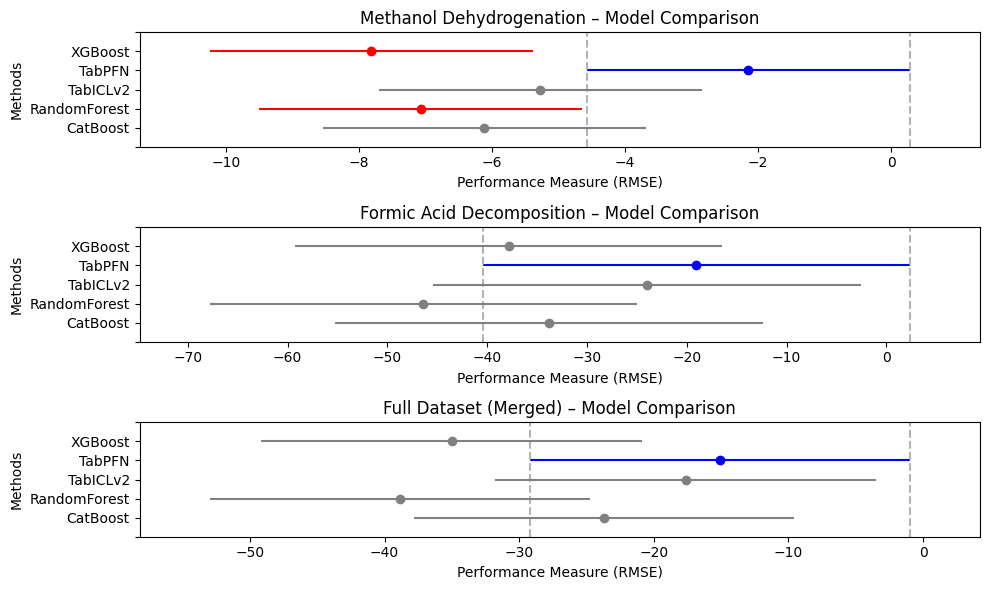

In [25]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Helper function to convert scores to tukey plots

def tukey_plot_from_scores(scores_dict, comparison_name, title, ax):
    # Convert dict of lists to long DataFrame
    data = []
    for model_name, model_scores in scores_dict.items():
        for s in model_scores:
            data.append({"Model": model_name, "Score": s})
    df_long = pd.DataFrame(data)

    # Tukey HSD
    tukey = pairwise_tukeyhsd(
        endog=df_long["Score"],
        groups=df_long["Model"],
        alpha=0.05
    )

    # Plot on the provided axis
    fig = tukey.plot_simultaneous(
        comparison_name=comparison_name,
        ax=ax
    )

    # Aesthetics
    ax.set_title(title)
    ax.set_xlabel("Performance Measure (RMSE)")
    ax.set_ylabel("Methods")

# Create figure

fig, axes = plt.subplots(3, 1, figsize=(22, 6), sharex=False, sharey=False)

tukey_plot_from_scores(
    scores_methanol,
    comparison_name="TabPFN",
    title="Methanol Dehydrogenation – Model Comparison",
    ax=axes[0]
)

tukey_plot_from_scores(
    scores_formic,
    comparison_name="TabPFN",
    title="Formic Acid Decomposition – Model Comparison",
    ax=axes[1]
)

tukey_plot_from_scores(
    scores_full,
    comparison_name="TabPFN",
    title="Full Dataset (Merged) – Model Comparison",
    ax=axes[2]
)

plt.tight_layout()
plt.show()

